<a href="https://www.kaggle.com/code/cmdcrypto/disaster-images?scriptVersionId=333072857" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

#import numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
path = "/kaggle/input/datasets/mikolajbabula/disaster-images-dataset-cnn-model/DisasterModel/"

In [3]:
os.listdir(path)

['Cyclone_Wildfire_Flood_Earthquake_Dataset', 'validation', 'test', 'train']

In [4]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,MaxPooling2D, Dropout,BatchNormalization

In [5]:
train_ds = keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/datasets/mikolajbabula/disaster-images-dataset-cnn-model/DisasterModel/train",
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/datasets/mikolajbabula/disaster-images-dataset-cnn-model/DisasterModel/validation",
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)
test_ds = keras.utils.image_dataset_from_directory(
    directory="/kaggle/input/datasets/mikolajbabula/disaster-images-dataset-cnn-model/DisasterModel/test",
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 1600 files belonging to 4 classes.


I0000 00:00:1783327840.891263      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 400 files belonging to 4 classes.
Found 400 files belonging to 4 classes.


In [6]:
def process(image,label):
    image = tensorflow.cast(image,tensorflow.float64)/255.0
    return image, label

train_ds = train_ds.map(process)
test_ds = test_ds.map(process)
validation_ds = validation_ds.map(process)

In [7]:
train_ds

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [8]:
model = Sequential()
model.add(Conv2D(32,padding="same",kernel_size=(3,3),activation="relu",input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),padding="same"))

model.add(Conv2D(64,padding="same",kernel_size=(3,3),activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),padding="same"))

model.add(Conv2D(128,padding="same",kernel_size=(3,3),activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),padding="same"))

model.add(Conv2D(246,padding="same",kernel_size=(3,3),activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),padding="same"))

model.add(Flatten())

model.add(Dense(246,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(64,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(32,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(4,activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 246)    │       283,638 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 246)    │           984 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 246)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 246)            │    15,492,342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 246)            │           984 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 246)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        31,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,915,072 (60.71 MB)

 Trainable params: 15,913,192 (60.70 MB)

 Non-trainable params: 1,880 (7.34 KB)

In [9]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [10]:
from tensorflow.keras.callbacks import EarlyStopping
callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=5,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)


In [11]:
history = model.fit(train_ds,epochs=20,validation_data=validation_ds,callbacks=callback)

Epoch 1/20
 2/50 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.3203 - loss: 1.9703 

I0000 00:00:1783327859.745808      72 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 270ms/step - accuracy: 0.3719 - loss: 1.6762 - val_accuracy: 0.2525 - val_loss: 2.3812
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - accuracy: 0.5744 - loss: 1.0444 - val_accuracy: 0.2500 - val_loss: 2.5702
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.6737 - loss: 0.8802 - val_accuracy: 0.2500 - val_loss: 3.6313
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.7556 - loss: 0.6321 - val_accuracy: 0.2500 - val_loss: 2.7341
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.7950 - loss: 0.6032 - val_accuracy: 0.2575 - val_loss: 2.6706
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.8069 - loss: 0.5351 - val_accuracy: 0.2750 - val_loss: 3.0879


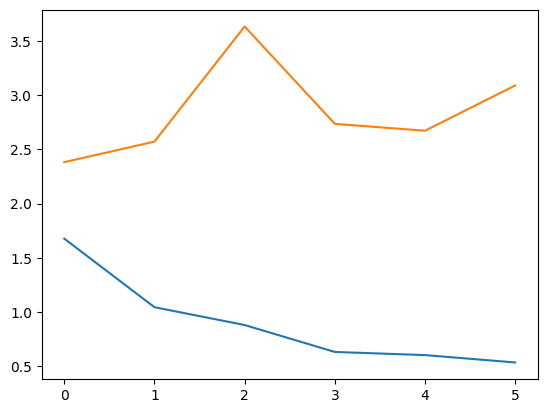

In [12]:
import matplotlib.pyplot as plt 
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

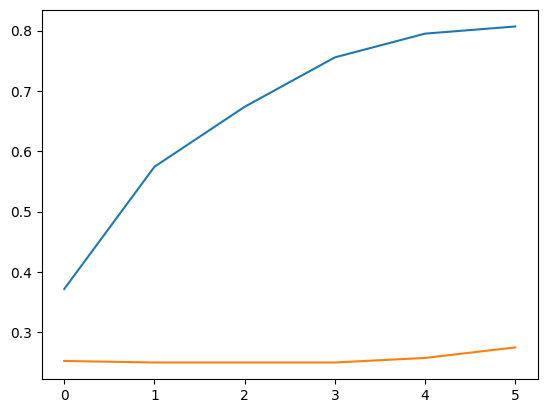

In [13]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

In [14]:
test_loss,test_acc = model.evaluate(test_ds)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.2650 - loss: 3.0284


In [15]:
test_loss,test_acc

(3.0284085273742676, 0.26499998569488525)

In [16]:
predictions =model.predict(test_ds).argmax(axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step


In [17]:
import numpy as np
predicted_class_index = np.argmax(predictions[0])
print(predicted_class_index)

0


In [18]:
import numpy as np
from tensorflow.keras.preprocessing import image

# 1. Define the path to a specific image inside your folders
img_path = '/kaggle/input/datasets/mikolajbabula/disaster-images-dataset-cnn-model/DisasterModel/test/earthquake/502.jpg' # Replace with a real file path!

# 2. Load the image and force it to match your input size
img = image.load_img(img_path, target_size=(256, 256))

# 3. Convert the visual image into a Numpy array of numbers
img_array = image.img_to_array(img)

# 4. Normalize the pixels (divide by 255.0, just like your 'process' function)
img_array = img_array / 255.0

# 5. Add a "batch" dimension
# The model expects a batch, even if it's a batch of 1. 
# This changes the shape from (256, 256, 3) to (1, 256, 256, 3)
img_array = np.expand_dims(img_array, axis=0)

# 6. Make the prediction
prediction = model.predict(img_array)

# 7. Get the final result
predicted_class_index = np.argmax(prediction)
print(f"The model predicts this image is class index: {predicted_class_index}")
print(f"Raw probability scores: {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
The model predicts this image is class index: 3
Raw probability scores: [[0.01397894 0.01422409 0.17969355 0.7921034 ]]
